In [1]:
%cd ..

c:\Users\user\OneDrive\Desktop\170A-CHOC


In [2]:
import torch
import pandas as pd
import numpy as np
import random
import os
import torch.nn as nn
from torch.distributions import Beta
from functools import partial
from data.data_partitioner import DataPartitioner

In [3]:
def set_seed(seed=42):
    # 1. Basic Python and NumPy seeds
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    
    # 2. PyTorch seeds
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # for multi-GPU
    
    # 3. Force CuDNN to be deterministic (Note: this can slightly slow down training)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [4]:
def data_prep(df, drop, target):
    df_enc = pd.get_dummies(df).astype(int)
    return torch.tensor(df_enc.drop(drop, axis=1).values).float(), torch.tensor(df_enc[target].values).float()

In [5]:
choc_data_prep = partial(data_prep, drop=['no_show_Yes','no_show_No', 'NOSHOWS_365'], target='no_show_Yes')

In [6]:
data = DataPartitioner(data_dir='data')
data.load_datasets()

In [8]:
X_train, y_train = choc_data_prep(data.choc)
X_test, y_test = choc_data_prep(data.choc_svi[data.choc.columns.tolist()])
X_eval, y_eval = choc_data_prep(data.choc_svi_coi[data.choc.columns.tolist()])

In [12]:
def forward_df(X, y, model):
    # 1. Get the tuple from the model
    alpha, beta, p_mean = model(X)

    # 2. Combine them with y_train into a single list
    # We ensure y_train is the correct shape using .view(-1)
    all_tensors = [alpha, beta, p_mean, y.view(-1)]

    # 3. Stack them horizontally, detach, and convert
    return pd.DataFrame(
        torch.stack(all_tensors, dim=1).detach().cpu().numpy(),
        columns=['alpha', 'beta', 'p_mean', 'no_show']
    )

In [13]:
def result_aggregation(df):
    df['bin'] = pd.cut(df['p_mean'], 10)
    return df[['bin','no_show']].groupby('bin').agg(['size','mean'])

In [14]:
class BayesianWeightNet(nn.Module):
    def __init__(self):
        super(BayesianWeightNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(51, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2)  # Two outputs: one for Alpha, one for Beta
        )

    def forward(self, X):
        # Pass features through the network
        out = self.net(X)
        
        # Split the output into Alpha and Beta components
        # out[:, 0] is Alpha, out[:, 1] is Beta
        # We use softplus to ensure alpha/beta > 0
        # Adding a small constant (1e-6) provides numerical stability
        alpha = nn.functional.softplus(out[:, 0]) + 1.0
        beta = nn.functional.softplus(out[:, 1]) + 1.0
        # 2. Multi-sample Thompson Sampling
        dist = torch.distributions.Beta(alpha, beta)
        
        # rsample with sample_shape=(100,)
        # Resulting shape: [100, batch_size, 1]
        samples = dist.rsample(sample_shape=torch.Size([100]))
        
        # Take the mean across the 100 samples (dim 0)
        # This reduces shape back to [batch_size, 1]
        p_sampled = samples.mean(dim=0)
        return alpha, beta, p_sampled

In [15]:
# 1. Setup ---
model = BayesianWeightNet()
optimizer = torch.optim.Adam(model.parameters(), lr=0.015)

# Assuming X_train and y_train are your tensors
dataset = torch.utils.data.TensorDataset(X_train, y_train)

In [16]:
# from torch.utils.data import WeightedRandomSampler

# Create weights for every individual sample in the dataset
# 1/12 for minority, 1/88 for majority
# weights = [1/12 if label == 1 else 1/88 for label in y_train]
# sampler = WeightedRandomSampler(weights, len(weights))

# Your loader will now see 50% zeros and 50% ones in every batch
loader = torch.utils.data.DataLoader(dataset, batch_size=32, 
                                    #  sampler=sampler
                                     )
model.train()

BayesianWeightNet(
  (net): Sequential(
    (0): Linear(in_features=51, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=2, bias=True)
  )
)

In [17]:
# Calculate weight: 88 / 12 = 7.33
# This tells the model: "A mistake on a '1' is 7.33x more important than a '0'"
pos_weight = torch.tensor([7.33]) 

# Use the BCEWithLogits equivalent or functional version with manual weighting
def weighted_bce(prediction, target, pos_weight):
    # Standard BCE is: -(target * log(p) + (1-target) * log(1-p))
    # Weighted BCE is: -(target * log(p) * pos_weight + (1-target) * log(1-p))
    loss = -(target * torch.log(prediction) * pos_weight + (1 - target) * torch.log(1 - prediction))
    return loss.mean()

In [18]:
epochs = 5
for epoch in range(epochs):
    epoch_loss = 0.0
    
    for X_batch, target_batch in loader:
        optimizer.zero_grad()

        # 1. Forward pass
        alpha, beta, p_sampled = model(X_batch)

        # 3. Binary Cross Entropy Loss
        p_sampled = torch.clamp(p_sampled, 1e-7, 1.0 - 1e-7)
        loss = nn.functional.binary_cross_entropy(p_sampled, target_batch)

        # 4. Backward pass
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        
    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss/len(loader):.4f}")

Epoch 1/5 | Loss: 0.3730
Epoch 2/5 | Loss: 0.3623
Epoch 3/5 | Loss: 0.3595
Epoch 4/5 | Loss: 0.3581
Epoch 5/5 | Loss: 0.3566


In [19]:
model.forward(X_train)

(tensor([1., 1., 1.,  ..., 1., 1., 1.], grad_fn=<AddBackward0>),
 tensor([12.8549, 21.2901, 13.5125,  ..., 14.5404, 14.0593,  6.9439],
        grad_fn=<AddBackward0>),
 tensor([0.0833, 0.0461, 0.0801,  ..., 0.0645, 0.0587, 0.1209],
        grad_fn=<MeanBackward1>))

In [20]:
forward_choc_df = partial(forward_df, model=model)

In [21]:
df = forward_choc_df(X=X_train, y=y_train)

In [22]:
result_aggregation(df)

C:\Users\user\AppData\Local\Temp\ipykernel_26604\3135445507.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df[['bin','no_show']].groupby('bin').agg(['size','mean'])


no_show          
                  size      mean
bin                             
(0.033, 0.121]   21737  0.095091
(0.121, 0.208]    8476  0.169302
(0.208, 0.295]     401  0.246883
(0.295, 0.383]      90  0.544444
(0.383, 0.47]       47  0.744681
(0.47, 0.557]       18  0.611111
(0.557, 0.644]       9  0.888889
(0.644, 0.731]      19  0.947368
(0.731, 0.819]     108  0.935185
(0.819, 0.906]      72  0.902778

In [23]:
df_test = forward_choc_df(X_test,y_test)

In [24]:
result_aggregation(df_test)

C:\Users\user\AppData\Local\Temp\ipykernel_26604\3135445507.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df[['bin','no_show']].groupby('bin').agg(['size','mean'])


no_show          
                   size      mean
bin                              
(0.0218, 0.111]   46279  0.084293
(0.111, 0.2]      20068  0.138380
(0.2, 0.288]       1056  0.206439
(0.288, 0.377]      130  0.584615
(0.377, 0.466]       63  0.666667
(0.466, 0.554]      101  0.534653
(0.554, 0.643]       29  0.862069
(0.643, 0.731]       60  0.916667
(0.731, 0.82]       274  0.919708
(0.82, 0.908]       131  0.908397

In [25]:
df_eval = forward_choc_df(X_eval,y_eval)

In [26]:
result_aggregation(df_eval)

C:\Users\user\AppData\Local\Temp\ipykernel_26604\3135445507.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df[['bin','no_show']].groupby('bin').agg(['size','mean'])


no_show          
                  size      mean
bin                             
(0.026, 0.116]  270961  0.093774
(0.116, 0.206]  178061  0.158305
(0.206, 0.295]    7090  0.226234
(0.295, 0.385]     661  0.488654
(0.385, 0.474]     445  0.631461
(0.474, 0.564]     304  0.513158
(0.564, 0.653]     137  0.781022
(0.653, 0.743]     195  0.897436
(0.743, 0.832]    1156  0.927336
(0.832, 0.922]     375  0.890667

Brier Score: 0.1055
ROC-AUC: 0.6186
Log-Loss: 0.3639


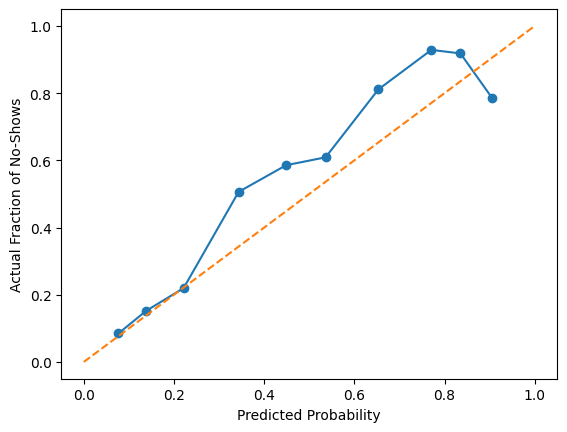

In [27]:
from sklearn.metrics import brier_score_loss, roc_auc_score, log_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
y_true = df_eval['no_show']
y_prob = df_eval['p_mean']
# Metrics
print(f"Brier Score: {brier_score_loss(y_true, y_prob):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
print(f"Log-Loss: {log_loss(y_true, y_prob):.4f}")

# Calibration Plot
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Fraction of No-Shows")
plt.show()

In [34]:
df_eval = df_eval.reset_index()

In [40]:
index_only = data.choc_svi_coi.drop(columns=data.choc.columns.tolist()).reset_index()

In [39]:
engineered_df = df_eval.merge(index_only,on='index').drop(columns=['index', 'bin'])

In [41]:
engineered_df.to_csv('data/engineered_data.csv')